# Esse é o run principal do PV
Para referências, ver o arquivo '/old_stuff/run.py'


## Iniciando variáveis de trabalho e carregando metadados
- Carregando as bibliotecas

In [1]:
from typing import Dict, Any
from pathlib import Path
from old_stuff.evidence_policy import EvidencePolicy
from old_stuff.run_config import RunConfig
from old_stuff.subject_recording import SubjectRecording
from old_stuff.derive_temporal import derive_temporal_protocol
from vars  import __version__, OPEN_LIMITATIONS, BLOCKED_ANALYSES, CHANGELOG_V24
from scipy import stats

from dataclasses import asdict
import old_stuff.qc as qc;
import old_stuff.utils as ut
import pandas as pd
import numpy as np
import json

pd.set_option('display.max_columns', None) # faz o pandas mostrar todas as colunas alinhadas
pd.set_option('display.width', 1000)

- Criando as variáveis de input!

In [2]:
eeg_dir = 'data/'
metadata_path = 'data/meta.xlsx'
output_dir = 'output/'
selection_criterion = 'A_definir'
cfg = RunConfig()
policy = EvidencePolicy()


- Carregando Metadados e pegando o nome dos arquivos disponíveis

In [3]:
qc.assert_qc_thresholds_frozen(cfg.qc_freeze, policy)  # B5
files, failures = ut.discover_eeg_files(eeg_dir)
metadata = ut.load_modma_metadata(metadata_path)

# --- Etapa 1: leitura, esquema, filtragem, QC e perfil temporal (cego ao rotulo) ---
recs: Dict[str, SubjectRecording] = {}
filtered_map: Dict[str, np.ndarray] = {}
qc_rows, block_rows, fs_rows = [], [], []

- Criando os diretórios de saída

In [4]:
out = Path(output_dir)
d_int, d_qual = out / "01_integration", out / "02_quality"
d_ana, d_sens = out / "03_analysis", out / "04_sensitivity"
for d in (d_int, d_qual, d_ana, d_sens):
    d.mkdir(parents=True, exist_ok=True)

## Fazendo a filtragem e análise dos arquivos

In [5]:
for fp in files:
    # print(['Arquivo', fp])
    try:
        rec = ut.load_modma_txt(fp, cfg.acquisition, fp.name, cfg.schema)
        if rec.subject_id in recs:
            raise ValueError("Sujeito duplicado: %s" % rec.subject_id)
        fsv = ut.verify_sampling_rate(rec.data_counts, cfg.acquisition)  # B2
        fsv["subject_id"] = rec.subject_id
        filt, fdiag = ut.preprocess_continuous(rec.data_counts, cfg.acquisition, cfg.preproc)
        prof = ut.block_profile(filt, cfg.acquisition.fs, cfg.temporal.block_seconds)
        prof["subject_id"] = rec.subject_id
        recs[rec.subject_id] = rec
        block_rows.append(prof)
        filtered_map[rec.subject_id] = filt
        # print(['Entrada da função',rec, filt, cfg.acquisition, cfg.features, fdiag])
        # print(['resultado da subeject_qc_metrics',ut.subject_qc_metrics(rec, filt, cfg.acquisition, cfg.features, fdiag)])
        qc_rows.append(ut.subject_qc_metrics(rec, filt, cfg.acquisition, cfg.features, fdiag))
        # print(prof)
        # print(block_rows)
        fs_rows.append(fsv)
    except Exception as exc:
        # print(['Erro em alguma função', exc])
        failures.append({"file": fp.name, "subject_id": fp.stem.split("_")[0],
                            "stage": "read_or_profile",
                            "error": "%s: %s" % (type(exc).__name__, str(exc)[:200])})
if not recs:
    raise RuntimeError("Nenhum registro utilizável.")

 ## Començando a análise dos dados


### B3: Referência espectral externa

- Calculando a coorte terminal.

In [9]:
print(block_rows[11])
# for b in block_rows:
    # print(b.shape)

    block_index  t_start_s   rms_counts  ocular_index  muscle_ratio  prof_delta  prof_theta  prof_alpha  prof_beta  prof_gamma_low subject_id
0             0        0.0   968.003170      0.775312      0.017745    0.797228    0.094077    0.074790   0.028688        0.005217   02010013
1             1       20.0   547.150969      0.426792      0.038794    0.499162    0.161076    0.262073   0.065257        0.012433   02010013
2             2       40.0   464.263518      0.330102      0.048544    0.388543    0.210379    0.307877   0.076644        0.016557   02010013
3             3       60.0   520.272640      0.503627      0.042135    0.579249    0.128581    0.214694   0.064434        0.013043   02010013
4             4       80.0   861.209124      0.698645      0.016271    0.720887    0.126545    0.117729   0.029482        0.005357   02010013
5             5      100.0   532.730657      0.381220      0.039858    0.459263    0.172969    0.279882   0.075677        0.012209   02010013
6     

In [ ]:

cohort_ref = ut.cohort_terminal_profile(block_rows, cfg.temporal)
print(cohort_ref)

IndexError: list index out of range

In [6]:
settle_rows = []
for prof in block_rows:
    sid = str(prof["subject_id"].iloc[0])
    st = ut.subject_settling_time(prof, cfg.temporal, cohort_ref_profile=cohort_ref)
    st["subject_id"] = sid
    st["duration_s"] = recs[sid].parse_report["duration_s"]
    settle_rows.append(st)
qc_df = qc.cohort_qc_decision(pd.DataFrame(qc_rows), cfg.qc)
qc_dist = qc.qc_distribution_report(qc_df, cfg.qc)                      # B5
settle_df = pd.DataFrame(settle_rows)
blocks_df = pd.concat(block_rows, ignore_index=True)
fs_df = pd.DataFrame(fs_rows)

### Etapa 2 - Passos A5/B3/B4 Derivação do protocolo temporal

In [7]:
durations = {s: r.parse_report["duration_s"] for s, r in recs.items()}
protocol = derive_temporal_protocol(settle_df, durations, cfg.temporal)
windows = protocol["sensitivity_windows"]
primary_start, primary_len = windows[0]

/Users/daniel/github/eeg/old_stuff/derive_temporal.py:49: RuntimeWarning: B4: inicio derivado (1180 s) excede max_skip_seconds (420 s) e foi truncado; a janela pode conter transitorio de acomodacao.
  warnings.warn("B4: inicio derivado (%.0f s) excede max_skip_seconds (%.0f s) e foi "


### Etapa 3 - features por janela

In [9]:
feat_by_window: Dict[str, pd.DataFrame] = {}
for (s0, L) in windows:
    rows = []
    for sid, rec in recs.items():
        if sid not in protocol["eligible_subjects"]:
            continue
        try:
            rows.append(ut.extract_features_for_window(filtered_map[sid], rec, cfg, s0, L))
            # print(rows)
        except Exception as exc:
            failures.append({"file": rec.source_name, "subject_id": sid,
                                "stage": "features_w%.0f" % s0,
                                "error": "%s: %s" % (type(exc).__name__, str(exc)[:200])})
    feat_by_window["w_%.0f_%.0f" % (s0, L)] = pd.DataFrame(rows)

In [29]:
key_primary = "w_%.0f_%.0f" % (primary_start, primary_len)
features = feat_by_window[key_primary]
# print(['features',features])

### Etapa 4 - pareamento e coorte analítica

In [ ]:
merged = features.merge(metadata, on="subject_id", how="left")
unmatched = merged.loc[merged["label"].isna(), "subject_id"].tolist()
merged = merged.loc[merged["label"].notna()].copy()
merged["label"] = merged["label"].astype(int)
qc_pass = set(qc_df.loc[qc_df["qc_pass"], "subject_id"])
merged["qc_pass"] = merged["subject_id"].isin(qc_pass)
drift_ok = ((pd.to_numeric(merged.get("drift_log2_rms"), errors="coerce")
                <= cfg.temporal.max_within_window_drift_log2)
            & (pd.to_numeric(merged.get("drift_js"), errors="coerce")
                <= cfg.temporal.max_within_window_js))
merged["drift_pass"] = drift_ok.fillna(False)



In [ ]:
analytic = merged.loc[merged["qc_pass"] & merged["drift_pass"]].reset_index(drop=True)

excl = merged.loc[~(merged["qc_pass"] & merged["drift_pass"])]
tab = pd.crosstab(merged["label"], merged["qc_pass"] & merged["drift_pass"])
fisher_p = (float(stats.fisher_exact(tab.to_numpy())[1])
            if tab.shape == (2, 2) else float("nan"))

- B6: falhas segregadas por estagio; 

A v23 somava leitura e janela no mesmo total, de modo que um sujeito podia ser contado ate 3 vezes como "arquivo que falhou".   

In [14]:
fail_df = pd.DataFrame(failures)
if not fail_df.empty and "stage" in fail_df.columns:
    by_stage = fail_df.groupby("stage").size().to_dict()
    subj_by_stage = {k: int(v["subject_id"].nunique())
                        for k, v in fail_df.groupby("stage")} if "subject_id" in fail_df else {}
    n_read_fail = int(fail_df.loc[fail_df["stage"].isin(
        ["discovery", "read_or_profile"])].shape[0])
else:
    by_stage, subj_by_stage, n_read_fail = {}, {}, 0

In [15]:
consort = {"n_files_found": len(files),
               "n_failures_total_events": int(len(failures)),
               "n_failures_read_stage": n_read_fail,
               "failures_by_stage": by_stage,
               "n_unique_subjects_failed_by_stage": subj_by_stage,
               "n_records_read": len(recs),
               "cohort_audit": ut.audit_expected_cohort(list(recs), cfg.cohort),
               "n_excluded_short_duration": len(protocol["excluded_short"]),
               "excluded_short_ids": protocol["excluded_short"],
               "n_with_features_primary_window": int(len(features)),
               "n_unmatched_metadata": len(unmatched), "unmatched_ids": unmatched,
               "n_after_qc_and_drift": int(len(analytic)),
               "n_excluded_qc_or_drift": int(len(excl)),
               "excluded_qc_ids": excl["subject_id"].tolist(),
               "differential_exclusion_fisher_p": fisher_p,
               "label_distribution_analytic": analytic["label"].value_counts().to_dict()}
print(consort)

{'n_files_found': 55, 'n_failures_total_events': 2, 'n_failures_read_stage': 0, 'failures_by_stage': {'features_w937': 2}, 'n_unique_subjects_failed_by_stage': {'features_w937': 2}, 'n_records_read': 55, 'cohort_audit': {'expected_declared': True, 'n_expected': 55, 'n_observed': 55, 'missing_ids': [], 'unexpected_ids': [], 'coverage': 1.0}, 'n_excluded_short_duration': 1, 'excluded_short_ids': ['02020018'], 'n_with_features_primary_window': 54, 'n_unmatched_metadata': 0, 'unmatched_ids': [], 'n_after_qc_and_drift': 17, 'n_excluded_qc_or_drift': 37, 'excluded_qc_ids': ['02010001', '02010002', '02010003', '02010005', '02010006', '02010007', '02010009', '02010011', '02010012', '02010014', '02010015', '02010016', '02010018', '02010022', '02010024', '02010025', '02010030', '02010035', '02010038', '02020007', '02020008', '02020011', '02020014', '02020015', '02020019', '02020022', '02020023', '02020025', '02030001', '02030002', '02030003', '02030005', '02030008', '02030009', '02030010', '0203

### Etapa 5: gravação dos artefatos de integração e qualidade


In [17]:
fail_df.to_csv(d_int / "failures.csv", index=False)
merged.to_csv(d_int / "features_primary_window.csv", index=False)
for k, v in feat_by_window.items():
    v.to_csv(d_sens / ("features_%s.csv" % k), index=False)
qc_df.to_csv(d_qual / "subject_qc.csv", index=False)
qc_dist.to_csv(d_qual / "qc_distribution.csv", index=False)           # B5
fs_df.to_csv(d_qual / "sampling_rate_verification.csv", index=False)  # B2
settle_df.to_csv(d_qual / "temporal_settling.csv", index=False)
blocks_df.to_csv(d_qual / "temporal_blocks.csv", index=False)

fs_summary = {"fs_assumed_hz": float(cfg.acquisition.fs),
                "fs_is_assumption": bool(cfg.acquisition.fs_is_assumption),
                "n_subjects_supporting_fs": int(fs_df.get("fs_supported",
                                                        pd.Series(dtype=bool)).sum()),
                "n_subjects_evaluated": int(len(fs_df)),
                "status_counts": (fs_df["fs_verification"].value_counts().to_dict()
                                if "fs_verification" in fs_df else {}),
                "note": ("A ausencia de pico de rede NAO refuta fs; deixa a suposicao sem "
                        "corroboracao. Se fs estiver errada, todas as bandas e todo o eixo "
                        "temporal escalam por um fator constante.")}

summary: Dict[str, Any] = {
    "version": __version__, "mode": policy.mode,
    "selection_criterion": selection_criterion,
    "config_fingerprint": cfg.fingerprint(),
    "sampling_rate_verification": fs_summary,
    "qc_thresholds_frozen": asdict(cfg.qc_freeze),
    "qc_threshold_impact": qc_dist.to_dict("records"),
    "temporal_protocol": protocol, "consort": consort,
    "open_limitations": list(OPEN_LIMITATIONS)}
if not protocol.get("protocol_valid", True):
    summary["protocol_warning"] = (
        "B4: o inicio derivado foi truncado por max_skip_seconds; a janela pode "
        "conter transitorio de acomodacao. Resultados temporais nao sao validos "
        "sob a regra declarada.")

<Axes: >

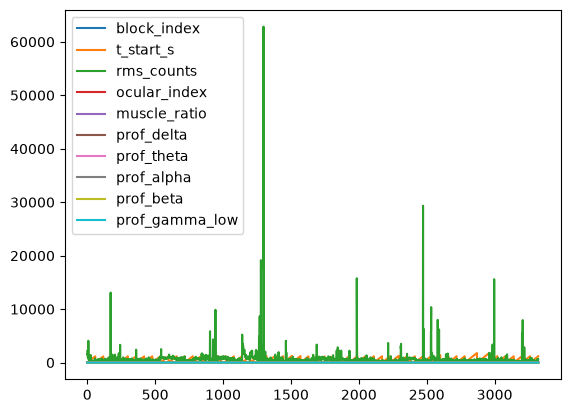

In [21]:
blocks_df.plot()

### Etapa 6: análise 

In [26]:
ok_cohort = (len(analytic) >= policy.min_subjects_for_ml
                 and analytic["label"].nunique() == 2
                 and analytic["label"].value_counts().min() >= policy.min_per_class_for_ml)
print(ok_cohort)
print([len(analytic),' > =policy.min_subjects_for_ml', policy.min_subjects_for_ml ])
if policy.mode == "integration" or not ok_cohort:
    print('ENTREI NESSE IF')
    summary["blocked_analyses"] = list(BLOCKED_ANALYSES)
    summary["block_reason"] = ("integration mode" if policy.mode == "integration"
                                else "coorte insuficiente")

False
[17, ' > =policy.min_subjects_for_ml', 20]
ENTREI NESSE IF


- Caso o if acima falhe:

In [ ]:
if policy.mode == "integration" or not ok_cohort:
     print('Entrei no if ok_cohort')
else:
    acfg = cfg.analysis
    conf = ut.confirmatory_group_tests(analytic, acfg)
    conf.to_csv(d_ana / "confirmatory_tests.csv", index=False)
    adj = ut.confound_adjusted_models(analytic, acfg)
    adj.to_csv(d_ana / "confound_adjusted_models.csv", index=False)
    batch = ut.batch_confound_report(analytic, acfg)
    cols = ut.primary_columns(analytic)
    X = analytic[cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    y = analytic["label"].to_numpy(int)
    res = ut.nested_cv_scores(X, y, acfg)
    met = ut.metrics_from_probs(y, res["prob_mean"], acfg,
                                oof_per_repeat=res["oof_prob_per_repeat"])  # B10
    covs = [c for c in acfg.covariates if c in analytic.columns]
    base = {"majority_class": {"balanced_accuracy": 0.5, "roc_auc": 0.5}}
    if covs:
        Xd = analytic[covs].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        if np.isfinite(Xd).any():
            rd = ut.nested_cv_scores(Xd, y, acfg)
            base["demographic"] = ut.metrics_from_probs(y, rd["prob_mean"], acfg,
                                                        rd["oof_prob_per_repeat"])
            rc = ut.nested_cv_scores(np.hstack([X, Xd]), y, acfg)
            base["eeg_plus_demographic"] = ut.metrics_from_probs(
                y, rc["prob_mean"], acfg, rc["oof_prob_per_repeat"])
        else:
            base["demographic"] = {"error": "covariaveis sem valores finitos (ver B9)"}
    # B1: observado e nulo sob o MESMO estimador
    obs_matched = ut.matched_observed_auc(X, y, acfg)
    perm = ut.permutation_auc_test(X, y, obs_matched, acfg)

    # B8: TODAS as janelas com o mesmo numero de repeticoes da primaria
    reps_sens = int(acfg.sensitivity_outer_repeats or acfg.outer_repeats)
    sens = {}
    for k, dfw in feat_by_window.items():
        m = dfw.merge(metadata, on="subject_id", how="inner")
        m = m.loc[m["subject_id"].isin(analytic["subject_id"])]
        if len(m) < policy.min_subjects_for_ml or m["label"].nunique() < 2:
            continue
        ck = ut.confirmatory_group_tests(m, acfg)
        Xk = m[cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        yk = m["label"].to_numpy(int)
        rk = ut.nested_cv_scores(Xk, yk, acfg, repeats=reps_sens)
        sens[k] = {"n": int(len(m)), "cv_repeats": reps_sens,
                    "roc_auc": float(roc_auc_score(yk, rk["prob_mean"])),
                    "effects": ck.set_index("feature")["hedges_g"].to_dict(),
                    "n_significant_fdr": int(ck["significant_fdr"].sum())}
        ck.to_csv(d_sens / ("confirmatory_%s.csv" % k), index=False)

    # B7: concordancia com IC e p binomial, sem veredito qualitativo
    gref = conf.set_index("feature")["hedges_g"]
    concord = {}
    for k, v in sens.items():
        if k == key_primary:
            continue
        c = ut.sign_agreement_with_ci(gref, pd.Series(v["effects"]),
                                    n_boot=acfg.sign_agreement_n_boot,
                                    seed=acfg.random_seed)
        c["roc_auc"] = v["roc_auc"]
        concord[k] = c

    summary["analysis"] = {
        "primary_window": {"start_s": primary_start, "seconds": primary_len},
        "cv_repeats_all_windows": reps_sens,
        "classification_eeg_primary": met, "baselines": base,
        "permutation_test": perm,
        "n_significant_fdr": int(conf["significant_fdr"].sum()),
        "confound_adjusted_available": bool(len(adj)),
        "batch_confound": batch, "window_sensitivity": sens,
        "window_concordance": concord,
        "interpretation_guard": (
            "Metricas sao de validacao interna em um unico conjunto, com poder para "
            "detectar apenas efeitos grandes (g >= 0,78 com 26 vs 28). "
            + ("Lote e diagnostico sao colineares (V = 1,00): NAO interprete como "
                "efeito clinico." if batch.get("batch_confounded") else ""))}
    json.dump(summary["analysis"], open(d_ana / "analysis_summary.json", "w"),
                indent=2, ensure_ascii=False, default=ut.json_default)

- Finalizando o run

In [28]:
manifest = {"version": __version__, "changelog": list(CHANGELOG_V24),
                "environment": ut.environment_manifest(), "config": asdict(cfg),
                "policy": asdict(policy), "selection_criterion": selection_criterion,
                "input_files": [{"name": p.name, "sha256": ut.sha256_file(p)} for p in files]}
json.dump(summary, open(out / "run_summary.json", "w"), indent=2,
            ensure_ascii=False, default=ut.json_default)
json.dump(manifest, open(out / "manifest.json", "w"), indent=2,
            ensure_ascii=False, default=ut.json_default)
output =  {"summary": summary, "manifest": manifest, "features": merged,
        "analytic": analytic, "qc": qc_df, "qc_distribution": qc_dist,
        "fs_verification": fs_df, "settling": settle_df,
        "features_by_window": feat_by_window, "failures": fail_df}
print(output['summary'])

{'version': '24.0.0', 'mode': 'integration', 'selection_criterion': 'A_definir', 'config_fingerprint': '38194a96b1e18654', 'sampling_rate_verification': {'fs_assumed_hz': 250.0, 'fs_is_assumption': True, 'n_subjects_supporting_fs': 55, 'n_subjects_evaluated': 55, 'status_counts': {'line_peak_at_expected_frequency': 55}, 'note': 'A ausencia de pico de rede NAO refuta fs; deixa a suposicao sem corroboracao. Se fs estiver errada, todas as bandas e todo o eixo temporal escalam por um fator constante.'}, 'qc_thresholds_frozen': {'thresholds_frozen': False, 'freeze_date': None, 'freeze_source': '', 'require_freeze_for_research': True}, 'qc_threshold_impact': [{'metric': 'line_noise_ratio_post', 'threshold_param': 'max_line_noise_ratio', 'threshold_value': 0.25, 'direction': 'greater', 'n_valid': 55, 'min': 6.735848316227673e-07, 'p05': 3.550621801545157e-06, 'q25': 1.0295773003078758e-05, 'median': 2.9100709316287803e-05, 'q75': 7.2001299512233e-05, 'p95': 0.0005656506184874283, 'max': 0.003